# 02 - K-Means on a Subsample  (Stage 2)

**Purpose.** Fit `MiniBatchKMeans` on a 200k subsample of `complete`
trajectories for several `k`, evaluate each `k` (inertia, silhouette, cluster
sizes, maps), and pickle every model so the best `k` can be chosen later.

**Input.** `data/features.parquet`  (Stage 1).
**Output.** `data/kmeans_models/scaler.pkl` (the shared StandardScaler),
`data/kmeans_models/kmeans_k*.pkl`, evaluation plots in `figures/`.

**Feature handling — z-standardization (this project's whole point).** The raw
features are the `2 × len(C.DAYS)` numbers `[lat_d, lon_d]` for every day in
`config.DAYS` (currently `[30, 50, 100, 150]` → `[lat_30, lon_30, …, lat_150,
lon_150]`) in degrees (`pipeline.build_feature_matrix`). We then **standardize
every column to mean 0 / std 1** with a single `StandardScaler` fit on the
subsample. This is what gives each day **equal weight**: particles disperse over
time, so the later day has the largest spatial variance and would otherwise
dominate the Euclidean distance k-means minimizes (k-means would effectively
weight the last day the most). Standardizing removes that bias. There is **no
spherical / haversine embedding** here — that would re-introduce a variance
imbalance. The scaler is saved and reused unchanged in notebooks 03 and 04.

**Per-day weighting (on top of standardization).** After standardizing, we
optionally re-weight each day on purpose via `config.DAY_WEIGHTS` (built into the
per-column multiplier `W = pipeline.feature_weight_vector()`, `W = sqrt(w)` per
column). Multiplying a standardized column by `sqrt(w)` scales its variance — and
hence that day's contribution to the k-means squared-distance objective — by
exactly `w`. This lets the **later position get more say** (where did the particle
end up?) while keeping the equal-variance baseline as the reference. The *same*
`W` is reapplied in notebooks 03 (predict) and 04 (centroids → degrees, dividing
by `W`); set every weight to 1.0 for pure equal-weight standardization.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # project root: config.py, pipeline.py
import numpy as np
import pandas as pd
import config as C
import pipeline as P
print("project root:", C.PROJECT_ROOT)
print("sampling days:", C.DAYS, "| feature space:", C.FEATURE_SPACE)

project root: /work/bk1450/b383184/Amazon/Mercator/notebooks/Analysis/kmeans_analysis/kmean_analysis_50_150_stdZ
sampling days: [30, 50, 100, 150] | feature space: zscore


## 2.1  Load features, take a 200k subsample, fit & save the StandardScaler

In [59]:
P.build_feature_matrix?

Signature: P.build_feature_matrix(df)
Docstring:
Turn the position columns into the RAW X matrix for k-means.

FEATURE_SPACE == 'zscore' (default, this project):
    raw geography -- one [lat, lon] pair per day in C.DAYS
    e.g. [lat50, lon50, lat100, lon100, lat150, lon150].
    Standardization to mean 0 / std 1 is applied SEPARATELY by the
    StandardScaler fit in notebook 02 (see `data/kmeans_models/scaler.pkl`);
    it is deliberately NOT baked in here so this returns interpretable
    degrees.
FEATURE_SPACE == 'xyz'    (legacy): each position -> unit-sphere (x, y, z).
FEATURE_SPACE == 'cosine' (legacy): [lat, lon*cos(MEAN_LAT)] per day.
File:      /work/bk1450/b383184/Amazon/Mercator/notebooks/Analysis/kmeans_analysis/kmean_analysis_50_150_stdZ/pipeline.py
Type:      function

In [2]:
import pickle
from sklearn.preprocessing import StandardScaler

features = pd.read_parquet(C.FEATURES_FILE)
complete = features[features.status == "complete"]
n_sub = min(C.N_SUB, len(complete))
sub = complete.sample(n=n_sub, random_state=C.RANDOM_STATE)

X_raw = P.build_feature_matrix(sub)          # raw degrees: [lat50,lon50,...,lon150]
scaler = StandardScaler().fit(X_raw)         # mean 0 / std 1 per column
X_sub = scaler.transform(X_raw)              # standardized space k-means sees
with open(C.MODELS_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print(f"complete: {len(complete):,}  ->  subsample: {X_sub.shape}")
print("feature columns:", P.feature_columns())
print("feature order          :", P.feature_columns())
print("per-column mean (deg)  :", np.round(scaler.mean_, 2))
print("per-column std  (deg)  :", np.round(scaler.scale_, 2),
      "  <- note how the later day has the larger spread that standardization equalizes")
print("after scaling -> mean  :", np.round(X_sub.mean(axis=0), 2), " (expect ~0)")
print("after scaling -> std   :", np.round(X_sub.std(axis=0), 2), " (expect ~1 -> equal weight per day)")

complete: 15,679,487  ->  subsample: (200000, 8)
feature columns: ['lat_30', 'lon_30', 'lat_50', 'lon_50', 'lat_100', 'lon_100', 'lat_150', 'lon_150']
feature order          : ['lat_30', 'lon_30', 'lat_50', 'lon_50', 'lat_100', 'lon_100', 'lat_150', 'lon_150']
per-column mean (deg)  : [  3.79 -51.29   4.87 -52.26   6.34 -54.35   7.33 -56.35]
per-column std  (deg)  : [2.83 2.02 3.76 3.39 5.33 6.74 6.33 9.07]   <- note how the later day has the larger spread that standardization equalizes
after scaling -> mean  : [ 0. -0.  0. -0. -0. -0. -0.  0.]  (expect ~0)
after scaling -> std   : [1. 1. 1. 1. 1. 1. 1. 1.]  (expect ~1 -> equal weight per day)


In [3]:
# --- Per-day feature weighting (applied AFTER z-standardization) -----------
# Columns are [lat_d, lon_d] per day in C.DAYS, i.e.
#   [lat_30, lon_30, lat_50, lon_50, lat_100, lon_100, lat_150, lon_150]
# In z-scored space every day already has equal variance (std=1). Multiplying a
# column by sqrt(w) scales its variance by w, so w is the effective weight of
# that day's squared distance in the k-means objective. Later days get more say
# (where did the particle end up?).
#
# The weights live in config.DAY_WEIGHTS (single source of truth) and the
# per-column multiplier W is built by pipeline.feature_weight_vector(), so
# notebooks 03 (predict) and 04 (centroid degrees) apply the SAME weighting
# instead of silently dropping it.
W = P.feature_weight_vector()   # sqrt(w) per column, aligned to P.feature_columns()
assert W.shape[0] == X_sub.shape[1], "W must have one entry per feature column"

# Reassign X_sub IN PLACE of the plain standardized matrix so EVERYTHING
# downstream (k-means fit, predict, centroid plots) sees the weighting.
# Rebuilt from X_raw each run, so re-executing this cell is idempotent.
X_sub = scaler.transform(X_raw) * W

print("per-day weights   :", C.DAY_WEIGHTS)
print("per-column sqrt(w):", dict(zip(P.feature_columns(), W.round(3))))
print("weighted std      :", np.round(X_sub.std(axis=0), 3),
      " (each pair now ~sqrt(w); was ~1)")

per-day weights   : {30: 1.0, 50: 2.0, 100: 1.0, 150: 2.0}
per-column sqrt(w): {'lat_30': np.float64(1.0), 'lon_30': np.float64(1.0), 'lat_50': np.float64(1.414), 'lon_50': np.float64(1.414), 'lat_100': np.float64(1.0), 'lon_100': np.float64(1.0), 'lat_150': np.float64(1.414), 'lon_150': np.float64(1.414)}
weighted std      : [1.    1.    1.414 1.414 1.    1.    1.414 1.414]  (each pair now ~sqrt(w); was ~1)


## 2.2  Fit MiniBatchKMeans for each k and evaluate (in standardized space)

In [4]:
import time
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

results = []
for k in C.K_LIST:
    t0 = time.time()
    km = MiniBatchKMeans(n_clusters=k, random_state=C.RANDOM_STATE,
                         batch_size=10000, n_init=10, max_iter=300)
    labels = km.fit_predict(X_sub)
    sil = silhouette_score(X_sub, labels, sample_size=C.SILHOUETTE_SAMPLE,
                           random_state=C.RANDOM_STATE)
    sizes = np.bincount(labels, minlength=k)
    with open(C.MODELS_DIR / f"kmeans_k{k}.pkl", "wb") as f:
        pickle.dump(km, f)
    results.append(dict(k=k, inertia=km.inertia_, silhouette=sil,
                        min_size=sizes.min(), max_size=sizes.max()))
    print(f"k={k:2d}  inertia={km.inertia_:.1f}  silhouette={sil:.3f}  "
          f"sizes[{sizes.min()}..{sizes.max()}]  ({time.time()-t0:.1f}s)")

res = pd.DataFrame(results)
res

k=15  inertia=204300.6  silhouette=0.330  sizes[3531..53518]  (24.1s)
k=20  inertia=174089.1  silhouette=0.335  sizes[1913..53627]  (22.9s)
k=25  inertia=154653.8  silhouette=0.345  sizes[1841..47406]  (23.0s)
k=30  inertia=139643.4  silhouette=0.355  sizes[1009..46832]  (22.5s)
k=35  inertia=131926.7  silhouette=0.347  sizes[915..44988]  (22.7s)
k=40  inertia=121288.7  silhouette=0.359  sizes[945..46132]  (22.7s)
k=45  inertia=117836.3  silhouette=0.341  sizes[738..38876]  (22.2s)
k=50  inertia=111806.1  silhouette=0.311  sizes[680..30741]  (22.2s)
k=55  inertia=106892.3  silhouette=0.307  sizes[482..33685]  (22.3s)


,k,inertia,silhouette,min_size,max_size
0,15,204300.610568,0.329653,3531,53518
1,20,174089.108860,0.334848,1913,53627
2,25,154653.796506,0.345353,1841,47406
3,30,139643.375053,0.355478,1009,46832
4,35,131926.680908,0.347491,915,44988
5,40,121288.714910,0.359458,945,46132
6,45,117836.333198,0.340566,738,38876
7,50,111806.050109,0.311272,680,30741
8,55,106892.335658,0.307273,482,33685


## 2.3  Elbow and silhouette plots

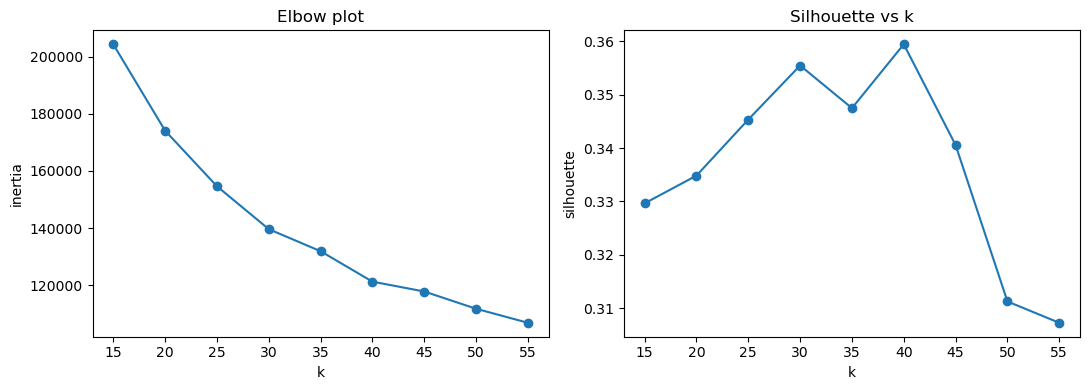

In [5]:
import matplotlib.pyplot as plt
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(res.k, res.inertia, "o-"); a1.set_xlabel("k"); a1.set_ylabel("inertia")
a1.set_title("Elbow plot")
a2.plot(res.k, res.silhouette, "o-"); a2.set_xlabel("k")
a2.set_ylabel("silhouette"); a2.set_title("Silhouette vs k")
fig.tight_layout()
fig.savefig(C.FIG_DIR / "elbow_plot.png", dpi=130)
fig.savefig(C.FIG_DIR / "silhouette_plot.png", dpi=130)
plt.show()

## 2.4  Cluster maps for each k

For every `k`, colour the subsample's positions by cluster label so the spatial
structure can be judged by eye: day 50 = dots, day 100 = x, day 150 = +.

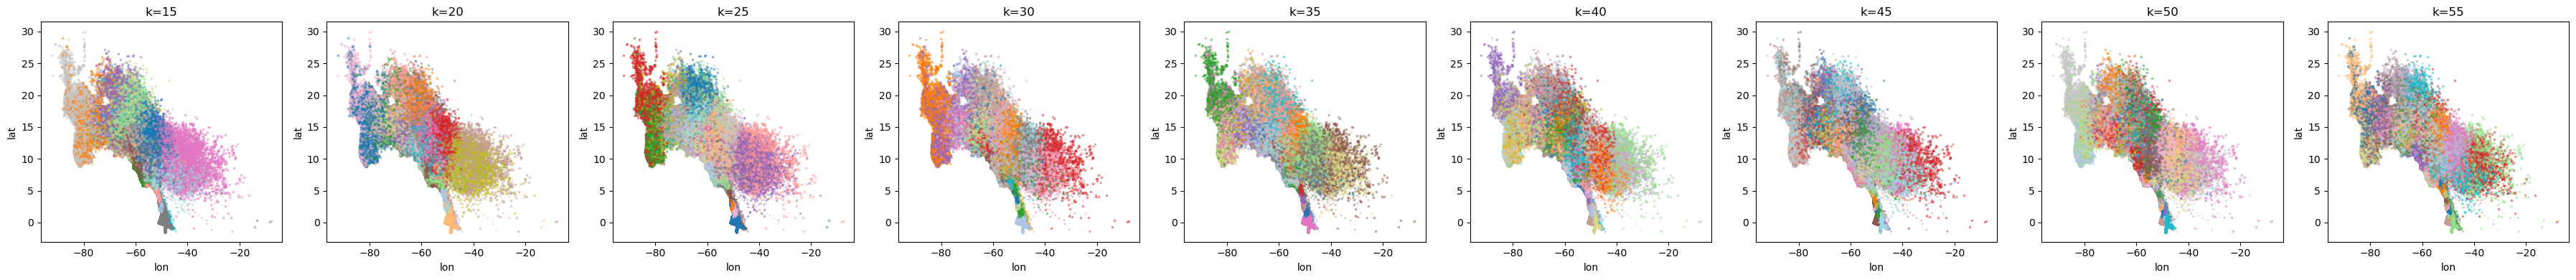

In [6]:
markers = {C.DAYS[0]: ".", }
fig, axes = plt.subplots(1, len(C.K_LIST), figsize=(4*len(C.K_LIST), 4), squeeze=False)
mk = ["o", "x", "+", "s", "d"]
for ax, k in zip(axes[0], C.K_LIST):
    with open(C.MODELS_DIR / f"kmeans_k{k}.pkl", "rb") as f:
        km = pickle.load(f)
    lab = km.predict(X_sub)
    for j, d in enumerate(C.DAYS):
        ax.scatter(sub[f"lon_{d}"], sub[f"lat_{d}"], c=lab, s=2, cmap="tab20",
                   marker=mk[j % len(mk)], alpha=.4)
    ax.set_title(f"k={k}"); ax.set_xlabel("lon"); ax.set_ylabel("lat")
fig.tight_layout()
fig.savefig(C.FIG_DIR / "cluster_maps_by_k.png", dpi=120)
plt.show()

## 2.5  Suggested cluster groupings (over-resolve, then merge)

We are **not** looking for a single "optimal" k. Instead pick a fairly high k
(e.g. 20-25) so the structure is over-resolved into many fine clusters, then
merge the fine clusters that represent the *same* physical pathway into a few
named groups.

The dendrogram below performs a Ward hierarchical clustering on the chosen
model's centroids **in the standardized space k-means was fit in** (so the merge
distances are consistent with the clustering). `pipeline.suggest_groups` cuts
that tree into `n_groups` and returns a `{raw_cluster: group}` map you can paste
into `config.GROUP_MAP` (and then refine by eye).

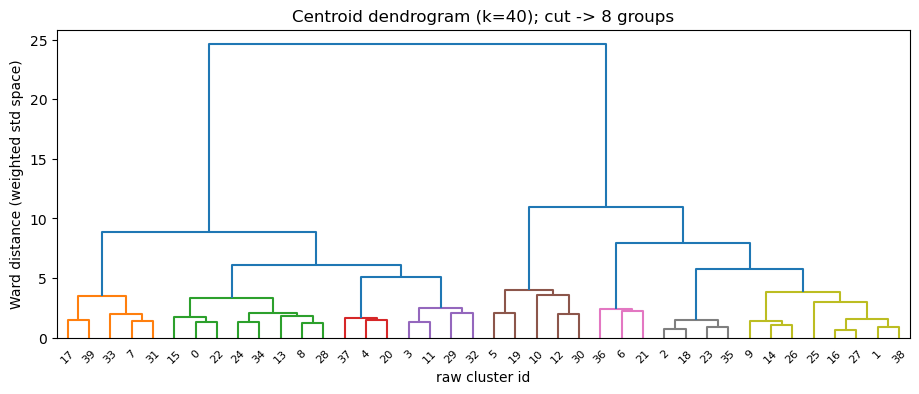

Suggested GROUP_MAP (paste into config.py, then refine):
GROUP_MAP = {0: 1, 1: 7, 2: 6, 3: 3, 4: 2, 5: 4, 6: 5, 7: 0, 8: 1, 9: 7, 10: 4, 11: 3, 12: 4, 13: 1, 14: 7, 15: 1, 16: 7, 17: 0, 18: 6, 19: 4, 20: 2, 21: 5, 22: 1, 23: 6, 24: 1, 25: 7, 26: 7, 27: 7, 28: 1, 29: 3, 30: 4, 31: 0, 32: 3, 33: 0, 34: 1, 35: 6, 36: 5, 37: 2, 38: 7, 39: 0}
  group 0: clusters [7, 17, 31, 33, 39]
  group 1: clusters [0, 8, 13, 15, 22, 24, 28, 34]
  group 2: clusters [4, 20, 37]
  group 3: clusters [3, 11, 29, 32]
  group 4: clusters [5, 10, 12, 19, 30]
  group 5: clusters [6, 21, 36]
  group 6: clusters [2, 18, 23, 35]
  group 7: clusters [1, 9, 14, 16, 25, 26, 27, 38]


In [53]:
from scipy.cluster.hierarchy import dendrogram

INSPECT_K = 40    # the k you want to take forward and group
N_GROUPS  = 8    # how many merged pathway groups you want to end up with

with open(C.MODELS_DIR / f"kmeans_k{INSPECT_K}.pkl", "rb") as f:
    km_i = pickle.load(f)
# Centroids live in WEIGHTED standardized space -> divide by W to undo the
# per-day weighting before inverse_transform gives back real degrees.
cent_deg = P.centroids_to_degrees(km_i.cluster_centers_ / W, scaler)   # readable labels
# Grouping is done in the weighted space k-means was fit in (keep the weights).
group_map, Z = P.suggest_groups(km_i.cluster_centers_, N_GROUPS)

fig, ax = plt.subplots(figsize=(11, 4))
dendrogram(Z, labels=[f"{c}" for c in range(INSPECT_K)], ax=ax,
           color_threshold=Z[-(N_GROUPS-1), 2])
ax.set_title(f"Centroid dendrogram (k={INSPECT_K}); cut -> {N_GROUPS} groups")
ax.set_xlabel("raw cluster id"); ax.set_ylabel("Ward distance (weighted std space)")
# fig.savefig(C.FIG_DIR / f"centroid_dendrogram_k{INSPECT_K}.png", dpi=130, bbox_inches="tight")
plt.show()

print("Suggested GROUP_MAP (paste into config.py, then refine):")
print("GROUP_MAP =", group_map)
for g in sorted(set(group_map.values())):
    members = [c for c, gg in group_map.items() if gg == g]
    print(f"  group {g}: clusters {members}")

### Numbered centroid map (eyeball the grouping alongside the dendrogram)

One big, readable map of the `k={INSPECT_K}` centroids in real degrees. Each
cluster's mean pathway is drawn day 50 -> 100 -> 150 (small -> large marker,
black edge on the final day); the cluster **number** sits at the day-150 end,
haloed in its **suggested group** colour. Read it together with the dendrogram:
numbers sharing a halo colour are the clusters `suggest_groups` wants to merge.
The map auto-fits to the centroids so nothing is cropped.

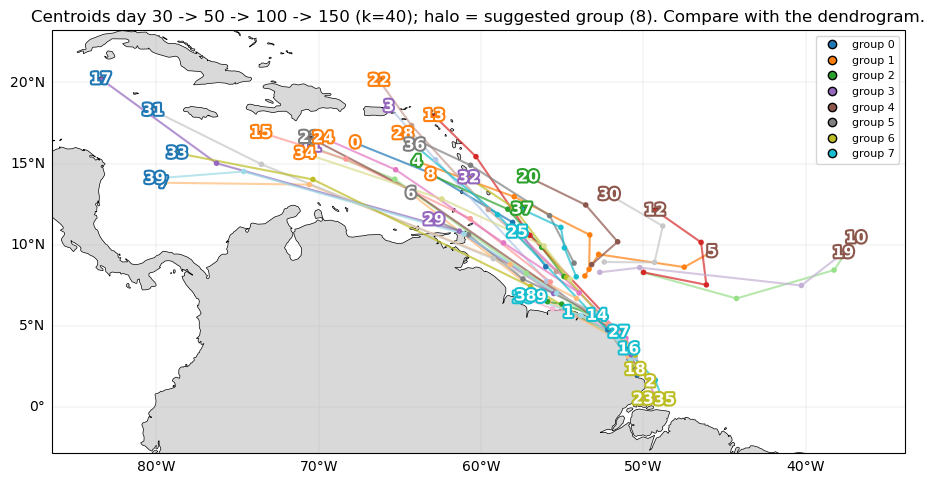

In [57]:
import matplotlib.patheffects as pe
from matplotlib.lines import Line2D
import cartopy.crs as ccrs, cartopy.feature as cfeature

cl_cmap   = plt.get_cmap("tab20", INSPECT_K)
grp_ids   = sorted(set(group_map.values()))
grp_cmap  = plt.get_cmap("tab10", max(len(grp_ids), 3))
grp_color = {g: grp_cmap(i) for i, g in enumerate(grp_ids)}

pc = ccrs.PlateCarree()
fig = plt.figure(figsize=(11, 8))
ax = plt.axes(projection=pc)
# auto-fit to the centroids (day150 disperses far) so nothing is cropped
lat_all = cent_deg[:, 0::2]; lon_all = cent_deg[:, 1::2]
ax.set_extent([lon_all.min()-3, lon_all.max()+3,
               lat_all.min()-3, lat_all.max()+3], crs=pc)
ax.add_feature(cfeature.LAND, facecolor="0.85"); ax.coastlines(lw=.5)
gl = ax.gridlines(draw_labels=True, lw=.3, color="0.7", alpha=.5)
gl.top_labels = gl.right_labels = False

day_sizes = [16, 16, 16, 16, 16, 16]   
for c in range(INSPECT_K):
    lats = cent_deg[c, 0::2]; lons = cent_deg[c, 1::2]   # one entry per day in C.DAYS
    ax.plot(lons, lats, "-", color=cl_cmap(c), lw=1.5, alpha=.7, transform=pc)
    for j in range(len(C.DAYS)):
        ax.scatter(lons[j], lats[j], s=day_sizes[j % len(day_sizes)], color=cl_cmap(c),
                   edgecolor="k" if j == len(C.DAYS) - 1 else "none", lw=.5,
                   zorder=3, transform=pc)
    # cluster number at the LAST day, haloed in its suggested group colour
    ax.text(lons[-1], lats[-1], str(c), fontsize=11, fontweight="bold",
            ha="center", va="center", color="white", zorder=4, transform=pc,
            path_effects=[pe.withStroke(linewidth=3, foreground=grp_color[group_map[c]])])

ax.set_title(f"Centroids day {' -> '.join(map(str, C.DAYS))} (k={INSPECT_K}); "
             f"halo = suggested group ({N_GROUPS}). Compare with the dendrogram.")
ax.legend(handles=[Line2D([0], [0], marker="o", ls="", mfc=grp_color[g], mec="k",
                          label=f"group {g}") for g in grp_ids], fontsize=8, loc="best")

fig.savefig(C.FIG_DIR / f"centroid_map_k{INSPECT_K}_{C.DAY_WEIGHTS}.png", dpi=130, bbox_inches="tight")
plt.show()

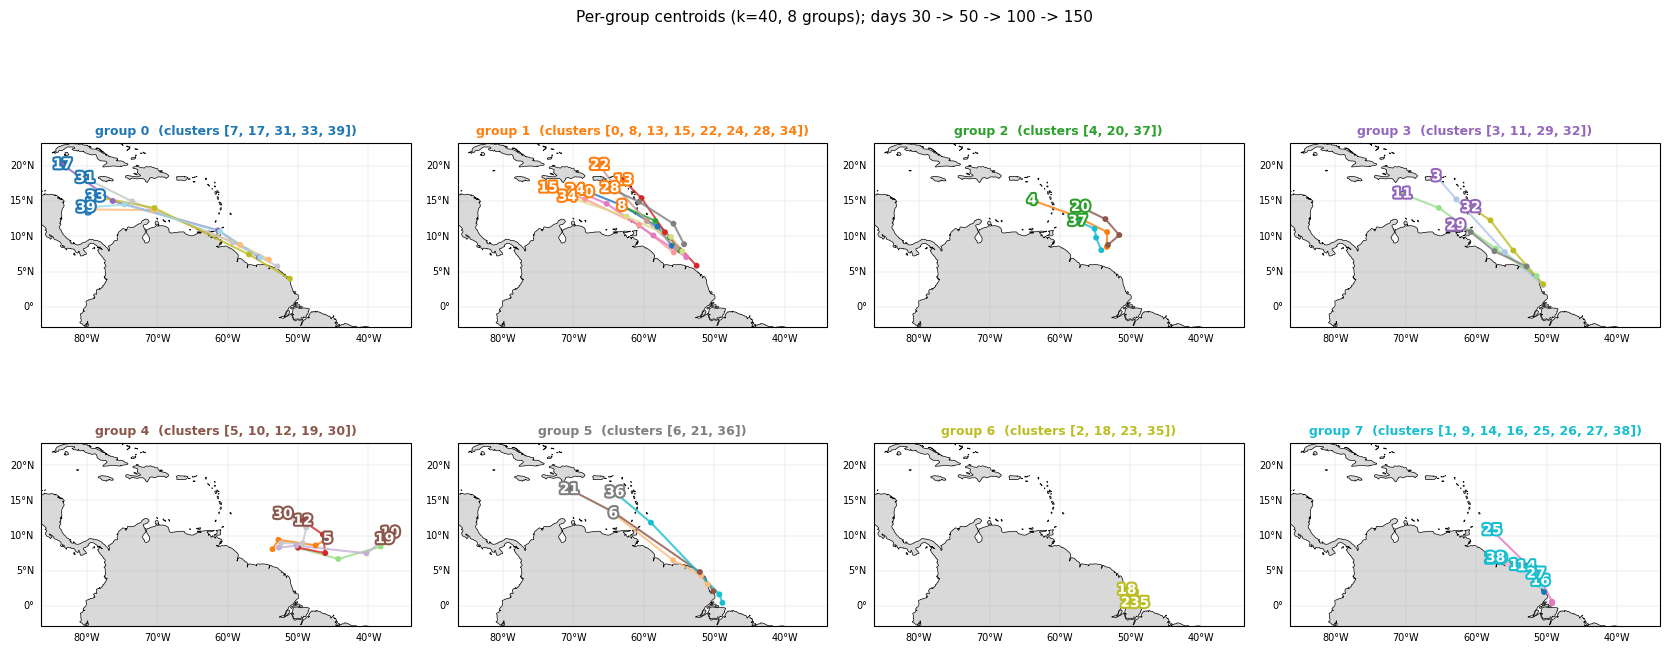

In [56]:
# --- One map per suggested group -------------------------------------------
# Small multiples: each panel shows only the clusters assigned to that group,
# using the SAME per-cluster colors (cl_cmap) and a SHARED extent so panels are
# directly comparable. Panel title is haloed/colored in the group color.
members = {g: [c for c in range(INSPECT_K) if group_map[c] == g] for g in grp_ids}

# shared extent = all centroids (+3 deg pad), same as the combined map above
ext = [lon_all.min() - 3, lon_all.max() + 3, lat_all.min() - 3, lat_all.max() + 3]

ncol = min(len(grp_ids), 4)
nrow = int(np.ceil(len(grp_ids) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.6 * nrow),
                         subplot_kw={"projection": pc}, squeeze=False)

for i, g in enumerate(grp_ids):
    ax = axes[i // ncol][i % ncol]
    ax.set_extent(ext, crs=pc)
    ax.add_feature(cfeature.LAND, facecolor="0.85"); ax.coastlines(lw=.5)
    gl = ax.gridlines(draw_labels=True, lw=.3, color="0.7", alpha=.5)
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = gl.ylabel_style = {"size": 7}

    for c in members[g]:
        lats = cent_deg[c, 0::2]; lons = cent_deg[c, 1::2]
        ax.plot(lons, lats, "-", color=cl_cmap(c), lw=1.5, alpha=.8, transform=pc)
        for j in range(len(C.DAYS)):
            ax.scatter(lons[j], lats[j], s=18, color=cl_cmap(c),
                       edgecolor="k" if j == len(C.DAYS) - 1 else "none", lw=.5,
                       zorder=3, transform=pc)
        ax.text(lons[-1], lats[-1], str(c), fontsize=10, fontweight="bold",
                ha="center", va="center", color="white", zorder=4, transform=pc,
                path_effects=[pe.withStroke(linewidth=3, foreground=grp_color[g])])

    ax.set_title(f"group {g}  (clusters {members[g]})", fontsize=9,
                 color=grp_color[g], fontweight="bold")

# blank any unused panels
for k in range(len(grp_ids), nrow * ncol):
    axes[k // ncol][k % ncol].axis("off")

fig.suptitle(f"Per-group centroids (k={INSPECT_K}, {N_GROUPS} groups); "
             f"days {' -> '.join(map(str, C.DAYS))}", y=1.0, fontsize=11)
fig.tight_layout()
fig.savefig(C.FIG_DIR / f"group_centroid_maps_k{INSPECT_K}_{C.DAY_WEIGHTS}.png", dpi=130, bbox_inches="tight")
plt.show()


In [63]:
print(f"centroid_map_k{INSPECT_K}_{C.DAY_WEIGHTS}")

centroid_map_k40_{30: 1.0, 50: 2.0, 100: 1.0, 150: 2.0}


## Group mapping

* 1st configuration: `centroid_map_k40_{30: 1.0, 50: 2.0, 100: 1.0, 150: 2.0}` with 8 groups of clusters. We merge the group of clusters ``1, 3, 5``. 

  - ```group 0: clusters [7, 17, 31, 33, 39]``` 
  - ```group 1: clusters [0, 8, 13, 15, 22, 24, 28, 34]```
  - ```group 2: clusters [4, 20, 37]```
  - ```group 3: clusters [3, 11, 29, 32]```
  - ```group 4: clusters [5, 10, 12, 19, 30]```
  - ```group 5: clusters [6, 21, 36]```
  - ```group 6: clusters [2, 18, 23, 35]```
  - ```group 7: clusters [1, 9, 14, 16, 25, 26, 27, 38]```

and we obtain: 

  - ```group A: clusters [7, 17, 31, 33, 39]``` 
  - ```group B: clusters [0, 8, 13, 15, 22, 24, 28, 34],[3, 11, 29, 32],[6, 21, 36]```
  - ```group C: clusters [4, 20, 37]```
  - ```group D: clusters [5, 10, 12, 19, 30]```
  - ```group E: clusters [2, 18, 23, 35]```
  - ```group F: clusters [1, 9, 14, 16, 25, 26, 27, 38]```

    - ```GROUP_MAP = {0: 1, 1: 5, 2: 4, 3: 1, 4: 2, 5: 3, 6: 1, 7: 0, 8: 1, 9: 5, 10: 3, 11: 1, 12: 3, 13: 1, 14: 5, 15: 1, 16: 5, 17: 0, 18: 4, 19: 3, 20: 2, 21: 1, 22: 1, 23: 4, 24: 1, 25: 5, 26: 5, 27: 5, 28: 1, 29: 1, 30: 3, 31: 0, 32: 1, 33: 0, 34: 1, 35: 4, 36: 1, 37: 2, 38: 5, 39: 0}```

## 2.6  Summary

Models for every k are pickled in `data/kmeans_models/` alongside the shared
`scaler.pkl`. Decide:
1. which **k** to carry forward (set `BEST_K` in notebooks 03 & 04), and
2. (optionally) the **GROUP_MAP** that merges fine clusters into pathway groups
   (paste into `config.py`).

If you set `GROUP_MAP`, notebooks 03 and 04 will additionally produce a
`cluster_group` column and group-level figures; if you leave it empty they fall
back to the raw clusters.

In [46]:
print("scaler saved:", (C.MODELS_DIR / "scaler.pkl").exists())
print("models saved:", sorted(p.name for p in C.MODELS_DIR.glob('kmeans_k*.pkl')))
print(res.to_string(index=False))

scaler saved: True
models saved: ['kmeans_k15.pkl', 'kmeans_k20.pkl', 'kmeans_k25.pkl', 'kmeans_k30.pkl', 'kmeans_k35.pkl', 'kmeans_k40.pkl', 'kmeans_k45.pkl', 'kmeans_k50.pkl', 'kmeans_k55.pkl']
 k       inertia  silhouette  min_size  max_size
15 204300.610568    0.329653      3531     53518
20 174089.108860    0.334848      1913     53627
25 154653.796506    0.345353      1841     47406
30 139643.375053    0.355478      1009     46832
35 131926.680908    0.347491       915     44988
40 121288.714910    0.359458       945     46132
45 117836.333198    0.340566       738     38876
50 111806.050109    0.311272       680     30741
55 106892.335658    0.307273       482     33685
